# Task 5: Cross-Domain Image Colorization

**Project:** Extension of Real-Time Image Colorization (Training Project)  
**New Features Added:**
- Domain router with domain-specific preprocessing (sketches, satellite/infrared, natural photos)
- Domain one-hot embedding fed into the colorization U-Net
- Training for 5 epochs across multiple domains jointly
- Domain selector simulation with comparative outputs

**Dataset:** EuroSAT (satellite imagery, via Kaggle) + Kaggle Image Colorization numpy set (natural photos, reused as the 'photo' domain) + synthetic edge-sketches generated from photos (the 'sketch' domain)

## Step 1: Install Dependencies

In [13]:
!pip install torch torchvision --quiet
!pip install opencv-python-headless --quiet
!pip install scikit-image --quiet
!pip install matplotlib tqdm kaggle --quiet
print('All dependencies installed!')

All dependencies installed!


## Step 2: Imports

In [14]:
import logging
logging.getLogger('PIL').setLevel(logging.ERROR)
import os, cv2, json, time, random, shutil, zipfile, urllib.request, glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from skimage import color
from skimage.metrics import structural_similarity as ssim

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Step 3: Download EuroSAT (Satellite Domain) via Kaggle

In [15]:
os.makedirs('eurosat', exist_ok=True)

KAGGLE_TOKEN = 'KGAT_2c7fc2df2c047f91c9b97fd55e5fda03'

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(KAGGLE_TOKEN)
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)

if not os.path.exists('eurosat/EuroSAT'):
    print('Downloading EuroSAT from Kaggle...')
    !KAGGLE_API_TOKEN=$KAGGLE_TOKEN kaggle datasets download -d apollo2506/eurosat-dataset -p eurosat
    print('Extracting...')
    for z in glob.glob('eurosat/*.zip'):
        with zipfile.ZipFile(z, 'r') as zf:
            zf.extractall('eurosat/')
    print('Done!')
else:
    print('Dataset already exists.')

Dataset already exists.


In [16]:
def safe_load_satellite(path, size=256):
    try:
        img = Image.open(path).convert('RGB').resize((size, size))
        return np.array(img)
    except Exception:
        return np.zeros((size, size, 3), dtype=np.uint8)


# Only collect jpg/png — skip .tif entirely (faster, avoids PIL spam)
satellite_imgs = []
for root, dirs, files_ in os.walk('eurosat'):
    for f in files_:
        if f.lower().endswith(('.jpg', '.png', '.jpeg')):
            satellite_imgs.append(os.path.join(root, f))

print(f'Satellite images found (jpg/png only): {len(satellite_imgs)}')
SATELLITE_PATHS = satellite_imgs[:1000]
print(f'Using: {len(SATELLITE_PATHS)} satellite images')

Satellite images found (jpg/png only): 27000
Using: 1000 satellite images


## Step 4: Download Natural Photo Domain (Kaggle numpy set)

In [17]:
os.makedirs('photo_data', exist_ok=True)

if not os.path.exists('photo_data/l'):
    print('Downloading photo dataset...')
    !KAGGLE_API_TOKEN=$KAGGLE_TOKEN kaggle datasets download -d shravankumar9892/image-colorization -p photo_data
    print('Extracting...')
    for z in glob.glob('photo_data/*.zip'):
        with zipfile.ZipFile(z, 'r') as zf:
            zf.extractall('photo_data/')
    print('Done!')
else:
    print('Photo dataset already exists.')

print('Loading photo numpy arrays...')
L_data_photo  = np.load('photo_data/l/gray_scale.npy')
ab1 = np.load('photo_data/ab/ab/ab1.npy')
ab2 = np.load('photo_data/ab/ab/ab2.npy')
ab3 = np.load('photo_data/ab/ab/ab3.npy')
ab_data_photo = np.concatenate([ab1, ab2, ab3], axis=0)

min_len = min(len(L_data_photo), len(ab_data_photo))
L_data_photo  = L_data_photo[:min_len][:1000]
ab_data_photo = ab_data_photo[:min_len][:1000]
print(f'Photo samples: {len(L_data_photo)}')

Photo dataset already exists.
Loading photo numpy arrays...
Photo samples: 1000


## Step 5: Generate Sketch Domain (Edge Detection from Photos)

Generating sketch domain from photo data...


  0%|          | 0/800 [00:00<?, ?it/s]/tmp/ipykernel_3860/3891388301.py:10: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 16381 negative Z values that have been clipped to zero
  rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/3891388301.py:10: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2331 negative Z values that have been clipped to zero
  rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/3891388301.py:10: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 20271 negative Z values that have been clipped to zero
  rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/3891388301.py:10: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 5414 negative Z values that have been clipped to zero
  rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipyker

Sketch samples generated: 800


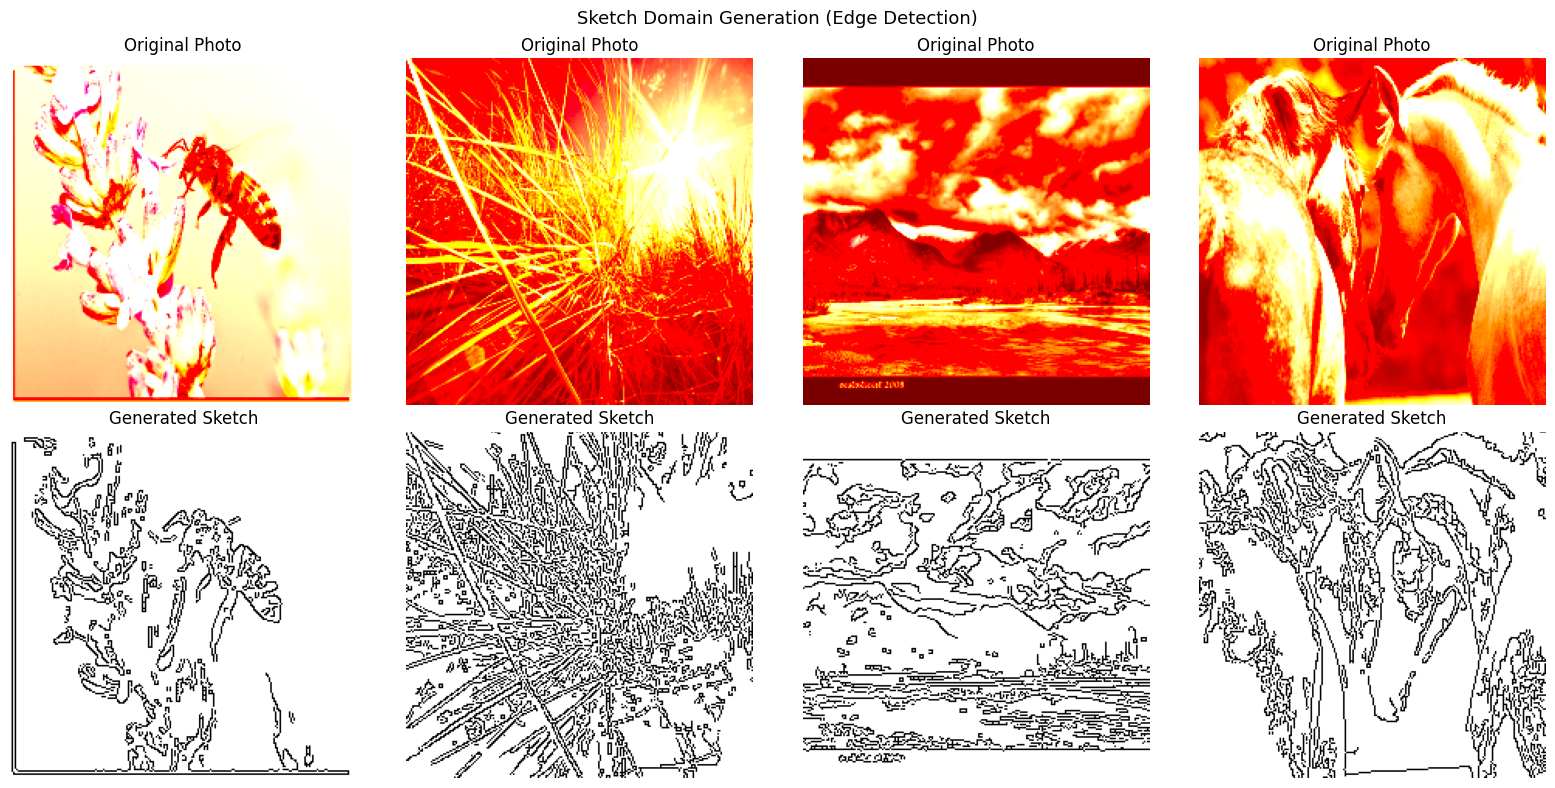

Sketch demo saved!


In [18]:
def photo_to_sketch(L_np, ab_np):
    """
    Convert a photo (from L+ab numpy) into a sketch-like edge image.
    Used to simulate the 'sketch' domain from real photo data.
    """
    if L_np.ndim == 3: L_np = L_np[:,:,0]
    if ab_np.ndim == 3 and ab_np.shape[0] == 2: ab_np = ab_np.transpose(1,2,0)

    lab = np.stack([L_np, ab_np[:,:,0], ab_np[:,:,1]], axis=2).astype(np.float32)
    rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)

    gray  = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    edges = cv2.bitwise_not(edges)
    sketch_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    return sketch_rgb, rgb


print('Generating sketch domain from photo data...')
sketch_inputs  = []
sketch_targets = []
for i in tqdm(range(min(800, len(L_data_photo)))):
    sketch_rgb, orig_rgb = photo_to_sketch(L_data_photo[i], ab_data_photo[i])
    sketch_inputs.append(sketch_rgb)
    sketch_targets.append(orig_rgb)

print(f'Sketch samples generated: {len(sketch_inputs)}')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
idxs = random.sample(range(len(sketch_inputs)), 4)
for col, idx in enumerate(idxs):
    axes[0, col].imshow(sketch_targets[idx]); axes[0, col].set_title('Original Photo')
    axes[1, col].imshow(sketch_inputs[idx]);  axes[1, col].set_title('Generated Sketch')
    axes[0, col].axis('off'); axes[1, col].axis('off')
plt.suptitle('Sketch Domain Generation (Edge Detection)', fontsize=13)
plt.tight_layout()
plt.savefig('sketch_domain_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sketch demo saved!')

## Step 6: Domain Definitions

Domains: ['photo', 'sketch', 'satellite']


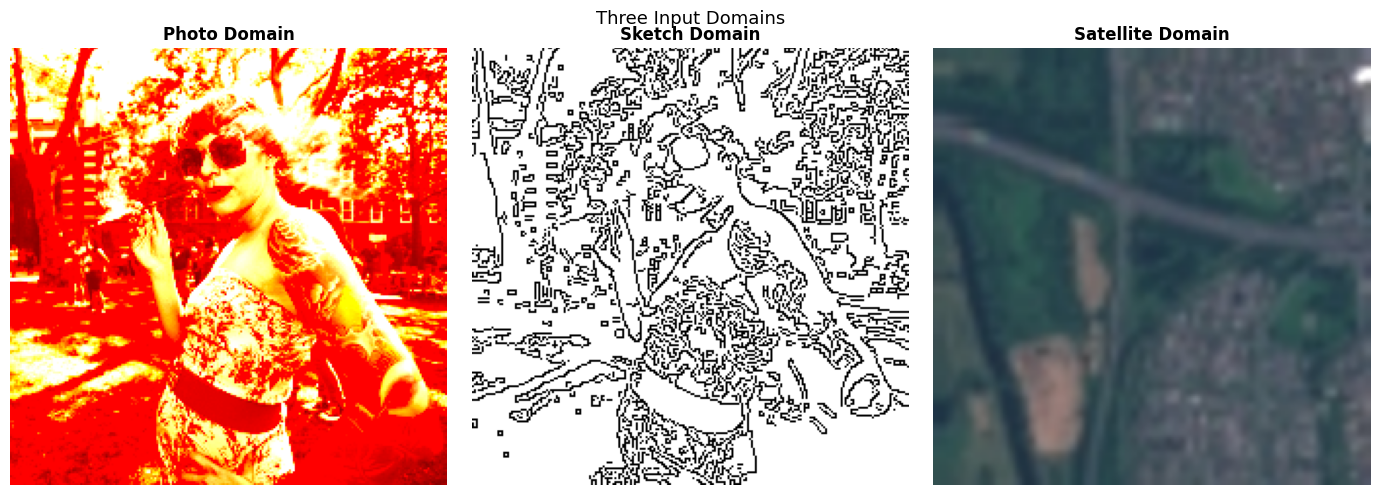

In [19]:
DOMAINS = {
    'photo':     {'label': 0, 'description': 'Natural photographs'},
    'sketch':    {'label': 1, 'description': 'Black & white line sketches'},
    'satellite': {'label': 2, 'description': 'Satellite/infrared imagery'},
}
DOMAIN_NAMES = list(DOMAINS.keys())
NUM_DOMAINS  = len(DOMAINS)
print(f'Domains: {DOMAIN_NAMES}')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(sketch_targets[0]); axes[0].set_title('Photo Domain', fontweight='bold')
axes[1].imshow(sketch_inputs[0]);  axes[1].set_title('Sketch Domain', fontweight='bold')
sat_img = safe_load_satellite(SATELLITE_PATHS[0])
axes[2].imshow(sat_img); axes[2].set_title('Satellite Domain', fontweight='bold')
for ax in axes: ax.axis('off')
plt.suptitle('Three Input Domains', fontsize=13)
plt.tight_layout()
plt.savefig('domain_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Cross-Domain Colorization U-Net
Input: L (1ch) + domain one-hot (3ch) = 4 channels  
Output: ab channels (2ch)

In [20]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class CrossDomainColorizationUNet(nn.Module):
    """
    Domain-conditioned colorization U-Net.
    Input:  [B, 4, H, W] — L + domain one-hot (3ch)
    Output: [B, 2, H, W] — ab channels
    """
    def __init__(self, num_domains=3):
        super().__init__()
        in_ch = 1 + num_domains
        self.pool = nn.MaxPool2d(2)
        self.enc1 = DoubleConv(in_ch, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.bottleneck = DoubleConv(512, 1024)
        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        self.out_conv = nn.Conv2d(64, 2, 1)
        self.tanh     = nn.Tanh()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.tanh(self.out_conv(d1))


model = CrossDomainColorizationUNet(num_domains=NUM_DOMAINS).to(device)
out   = model(torch.randn(2, 4, 256, 256).to(device))
print(f'Output shape: {out.shape}')
print(f'Total params: {sum(p.numel() for p in model.parameters()):,}')

Output shape: torch.Size([2, 2, 256, 256])
Total params: 31,044,162


## Step 8: Multi-Domain Dataset

In [21]:
class CrossDomainDataset(Dataset):
    """
    Unified dataset combining all 3 domains.
    Each item: (L + domain_onehot, target_ab, domain_label)
    """
    def __init__(self, size=256):
        self.size  = size
        self.items = []

        for i in range(len(L_data_photo)):
            self.items.append(('photo', i))
        for i in range(len(sketch_inputs)):
            self.items.append(('sketch', i))
        for i in range(len(SATELLITE_PATHS)):
            self.items.append(('satellite', i))

        random.shuffle(self.items)
        print(f'Total combined dataset: {len(self.items)} samples across 3 domains')

    def __len__(self): return len(self.items)

    def _to_lab_tensors(self, rgb_np):
        rgb_np  = cv2.resize(rgb_np, (self.size, self.size))
        img_f   = rgb_np.astype(np.float32) / 255.0
        img_lab = color.rgb2lab(img_f)
        L  = torch.FloatTensor(img_lab[:,:,0]).unsqueeze(0) / 50.0 - 1.0
        ab = torch.FloatTensor(img_lab[:,:,1:]).permute(2,0,1) / 128.0
        return L, ab

    def __getitem__(self, idx):
        domain_type, data_idx = self.items[idx]

        if domain_type == 'photo':
            L_np  = L_data_photo[data_idx].copy()
            ab_np = ab_data_photo[data_idx].copy()
            if L_np.ndim == 3: L_np = L_np[:,:,0]
            if ab_np.ndim == 3 and ab_np.shape[0] == 2: ab_np = ab_np.transpose(1,2,0)
            lab = np.stack([L_np, ab_np[:,:,0], ab_np[:,:,1]], axis=2).astype(np.float32)
            rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
            L, ab = self._to_lab_tensors(rgb)

        elif domain_type == 'sketch':
            sketch_rgb = sketch_inputs[data_idx]
            target_rgb = sketch_targets[data_idx]
            sketch_resized = cv2.resize(sketch_rgb, (self.size, self.size))
            sketch_gray = cv2.cvtColor(sketch_resized, cv2.COLOR_RGB2GRAY).astype(np.float32)
            L = torch.FloatTensor(sketch_gray).unsqueeze(0) / 127.5 - 1.0
            target_resized = cv2.resize(target_rgb, (self.size, self.size))
            target_lab = color.rgb2lab(target_resized.astype(np.float32)/255.0)
            ab = torch.FloatTensor(target_lab[:,:,1:]).permute(2,0,1) / 128.0

        else:  # satellite
            rgb = safe_load_satellite(SATELLITE_PATHS[data_idx], size=self.size)
            L, ab = self._to_lab_tensors(rgb)

        domain_label  = DOMAINS[domain_type]['label']
        domain_onehot = F.one_hot(
            torch.tensor(domain_label), num_classes=NUM_DOMAINS
        ).float().view(NUM_DOMAINS,1,1).expand(NUM_DOMAINS, self.size, self.size)

        model_input = torch.cat([L, domain_onehot], dim=0)  # [4, H, W]
        return model_input, ab, torch.tensor(domain_label)


full_dataset = CrossDomainDataset(size=256)
n     = len(full_dataset)
split = int(0.8 * n)
train_set, val_set = torch.utils.data.random_split(full_dataset, [split, n - split])

train_loader = DataLoader(train_set, batch_size=8, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train: {len(train_set)} | Val: {len(val_set)}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Total combined dataset: 2800 samples across 3 domains
Train: 2240 | Val: 560
Train batches: 280 | Val batches: 70


## Step 9: Training Setup

In [22]:
criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

NUM_EPOCHS     = 5
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print('Training config:')
print(f'  Epochs:      {NUM_EPOCHS}')
print(f'  Loss:        SmoothL1 (Huber)')
print(f'  Optimizer:   Adam (lr=1e-3)')
print(f'  Domains:     {DOMAIN_NAMES}')
print(f'  Batch size:  8')

Training config:
  Epochs:      5
  Loss:        SmoothL1 (Huber)
  Optimizer:   Adam (lr=1e-3)
  Domains:     ['photo', 'sketch', 'satellite']
  Batch size:  8


## Step 10: Training Loop (5 Epochs)

In [23]:
def run_epoch(model, loader, optimizer, criterion, is_train, epoch_num):
    model.train() if is_train else model.eval()
    total_loss = 0.0
    domain_losses = {d: [] for d in DOMAIN_NAMES}
    tag  = 'Train' if is_train else 'Val'
    pbar = tqdm(loader, desc=f'Epoch {epoch_num} [{tag}]', leave=False)
    ctx  = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for inputs, targets, domain_lbls in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            if is_train: optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, targets)
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()

            with torch.no_grad():
                per_sample = F.smooth_l1_loss(outputs, targets, reduction='none').mean(dim=[1,2,3])
                for d_idx, d_name in enumerate(DOMAIN_NAMES):
                    mask = (domain_lbls == d_idx)
                    if mask.sum() > 0:
                        domain_losses[d_name].extend(per_sample[mask].cpu().tolist())

            pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_domain_loss = {d: (np.mean(v) if len(v) > 0 else 0) for d, v in domain_losses.items()}
    return total_loss / len(loader), avg_domain_loss


train_losses, val_losses = [], []
domain_loss_history = []
best_val_loss = float('inf')

print(f'Starting training — {NUM_EPOCHS} epochs')
print('=' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    t_loss, t_dom = run_epoch(model, train_loader, optimizer, criterion, True,  epoch)
    v_loss, v_dom = run_epoch(model, val_loader,   optimizer, criterion, False, epoch)
    scheduler.step(v_loss)
    train_losses.append(t_loss); val_losses.append(v_loss)
    domain_loss_history.append(v_dom)
    elapsed = time.time() - t0
    dom_str = ' | '.join([f'{d}={v_dom[d]:.3f}' for d in DOMAIN_NAMES])
    print(f'Epoch [{epoch}/{NUM_EPOCHS}]  Train: {t_loss:.4f}  Val: {v_loss:.4f}  '
          f'[{dom_str}]  Time: {elapsed:.1f}s')

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'val_loss': v_loss}, f'{CHECKPOINT_DIR}/best_model.pth')
        print(f'         --> Best model saved (val={v_loss:.4f})')

print('=' * 70)
print(f'Training complete! Best val loss: {best_val_loss:.4f}')

Starting training — 5 epochs


Epoch 1 [Train]:   0%|          | 0/280 [00:00<?, ?it/s]/tmp/ipykernel_3860/2337770968.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 38043 negative Z values that have been clipped to zero
  rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/2337770968.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 10498 negative Z values that have been clipped to zero
  rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
Epoch 1 [Train]:   0%|          | 1/280 [00:00<03:10,  1.47it/s, loss=0.3016]/tmp/ipykernel_3860/2337770968.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 17399 negative Z values that have been clipped to zero
  rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/2337770968.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2161 negative Z values that have been

Epoch [1/5]  Train: 0.0192  Val: 0.0119  [photo=0.007 | sketch=0.032 | satellite=0.001]  Time: 207.4s
         --> Best model saved (val=0.0119)


Epoch [2/5]  Train: 0.0130  Val: 0.0160  [photo=0.019 | sketch=0.030 | satellite=0.002]  Time: 201.5s


Epoch [3/5]  Train: 0.0125  Val: 0.0120  [photo=0.006 | sketch=0.033 | satellite=0.001]  Time: 201.1s


Epoch [4/5]  Train: 0.0121  Val: 0.0115  [photo=0.007 | sketch=0.031 | satellite=0.001]  Time: 201.5s
         --> Best model saved (val=0.0115)


Epoch [5/5]  Train: 0.0120  Val: 0.0116  [photo=0.007 | sketch=0.030 | satellite=0.001]  Time: 202.1s
Training complete! Best val loss: 0.0115


## Step 11: Training Curves + Per-Domain Loss

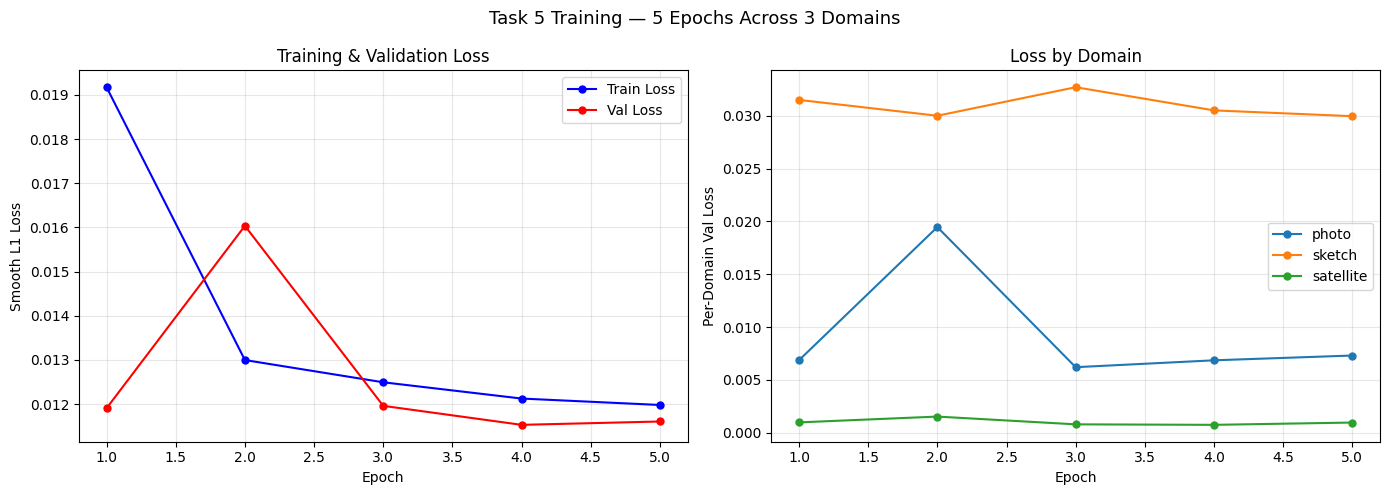

Train: 0.0192 → 0.0120
Val:   0.0119 → 0.0116


In [24]:
epochs = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, 'b-o', label='Train Loss', markersize=5)
axes[0].plot(epochs, val_losses,   'r-o', label='Val Loss',   markersize=5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Smooth L1 Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for d in DOMAIN_NAMES:
    vals = [h[d] for h in domain_loss_history]
    axes[1].plot(epochs, vals, '-o', label=d, markersize=5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Per-Domain Val Loss')
axes[1].set_title('Loss by Domain')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Task 5 Training — {NUM_EPOCHS} Epochs Across 3 Domains', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Train: {train_losses[0]:.4f} → {train_losses[-1]:.4f}')
print(f'Val:   {val_losses[0]:.4f} → {val_losses[-1]:.4f}')

## Step 12: Quality Metrics

In [25]:
def compute_colorfulness(img):
    img = img.astype(np.float32)
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    rg, yb  = R - G, 0.5*(R+G) - B
    return np.sqrt(np.std(rg)**2 + np.std(yb)**2) + 0.3*np.sqrt(np.mean(rg)**2 + np.mean(yb)**2)

def compute_saturation(img):
    hsv = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2HSV)
    return hsv[:,:,1].mean()

def compute_ssim(img1, img2):
    g1 = cv2.cvtColor(img1.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(img2.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    score, _ = ssim(g1, g2, full=True)
    return score

def lab_to_rgb(L_norm, ab_norm):
    L  = (L_norm[0].cpu().numpy() + 1.0) * 50.0
    ab = ab_norm.cpu().numpy() * 128.0
    lab = np.stack([L, ab[0], ab[1]], axis=2)
    return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)

print('Metric functions defined!')

Metric functions defined!


## Step 13: Evaluate Per-Domain

In [26]:
ckpt = torch.load(f'{CHECKPOINT_DIR}/best_model.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Best model loaded from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f})")

domain_metrics = {d: {'cf': [], 'sat': [], 'ssim': []} for d in DOMAIN_NAMES}
eval_ids = random.sample(range(len(val_set)), min(90, len(val_set)))

with torch.no_grad():
    for idx in tqdm(eval_ids, desc='Evaluating'):
        inp, tgt_ab, domain_lbl = val_set[idx]
        L_norm  = inp[:1]
        pred_ab = model(inp.unsqueeze(0).to(device)).squeeze(0).cpu()
        rgb_pred = lab_to_rgb(L_norm, pred_ab)
        rgb_gt   = lab_to_rgb(L_norm, tgt_ab)

        d_name = DOMAIN_NAMES[domain_lbl.item()]
        domain_metrics[d_name]['cf'].append(compute_colorfulness(rgb_pred))
        domain_metrics[d_name]['sat'].append(compute_saturation(rgb_pred))
        domain_metrics[d_name]['ssim'].append(compute_ssim(rgb_pred, rgb_gt))

print('\n=== Per-Domain Evaluation Results ===')
print(f'{"Domain":<12} {"Colorfulness":>14} {"Saturation":>12} {"SSIM":>10}')
print('-' * 50)
for d in DOMAIN_NAMES:
    cf  = np.mean(domain_metrics[d]['cf'])   if domain_metrics[d]['cf']   else 0
    sat = np.mean(domain_metrics[d]['sat'])  if domain_metrics[d]['sat']  else 0
    ss  = np.mean(domain_metrics[d]['ssim']) if domain_metrics[d]['ssim'] else 0
    print(f'{d:<12} {cf:>14.2f} {sat:>12.2f} {ss:>10.4f}')

Best model loaded from epoch 4 (val_loss=0.0115)


Evaluating:   6%|▌         | 5/90 [00:00<00:04, 19.84it/s]/tmp/ipykernel_3860/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 175 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 77 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/2337770968.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 24063 negative Z values that have been clipped to zero
  rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
Evaluating:   8%|▊         | 7/90 [00:00<00:04, 19.56it/s]/tmp/ipykernel_3860/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2585 negative Z values that have been clipped to zero
  retu


=== Per-Domain Evaluation Results ===
Domain         Colorfulness   Saturation       SSIM
--------------------------------------------------
photo                129.48       184.09     0.9289
sketch                62.70       116.88     0.9664
satellite             20.10        73.56     0.9962


## Step 14: Output Images — Per Domain

/tmp/ipykernel_3860/2337770968.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 8382 negative Z values that have been clipped to zero
  rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/2337770968.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 12416 negative Z values that have been clipped to zero
  rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/2337770968.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 35565 negative Z values that have been clipped to zero
  rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/2337770968.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 14866 negative Z values that have been clipped to zero
  rgb = np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/2337770968.py:39: UserWarning

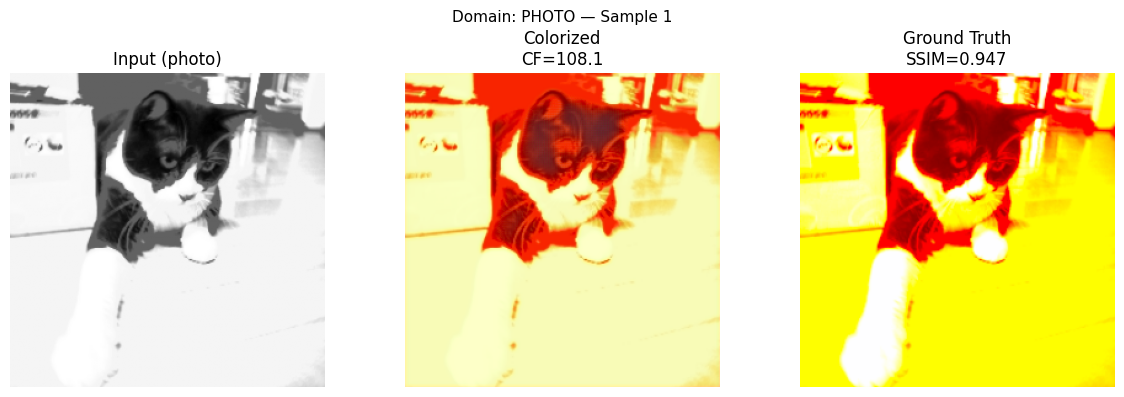

Saved result_1_photo.png — CF=108.1 SSIM=0.947


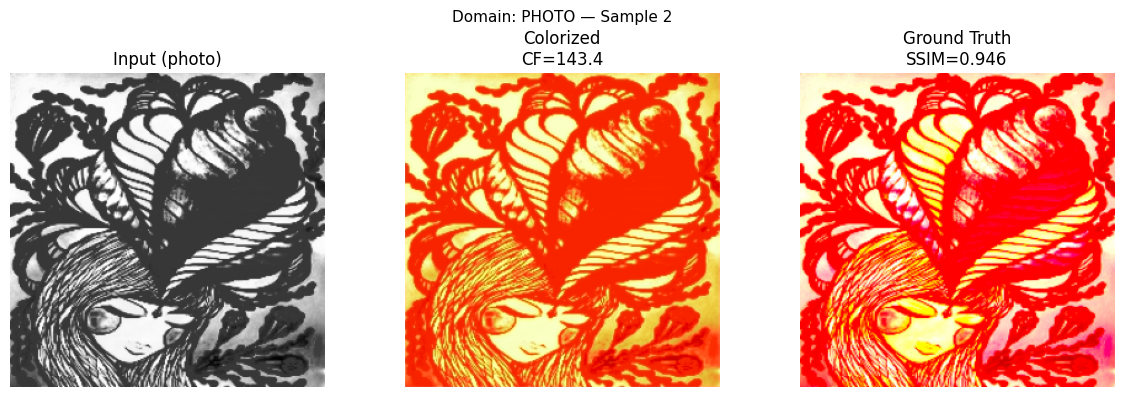

Saved result_2_photo.png — CF=143.4 SSIM=0.946


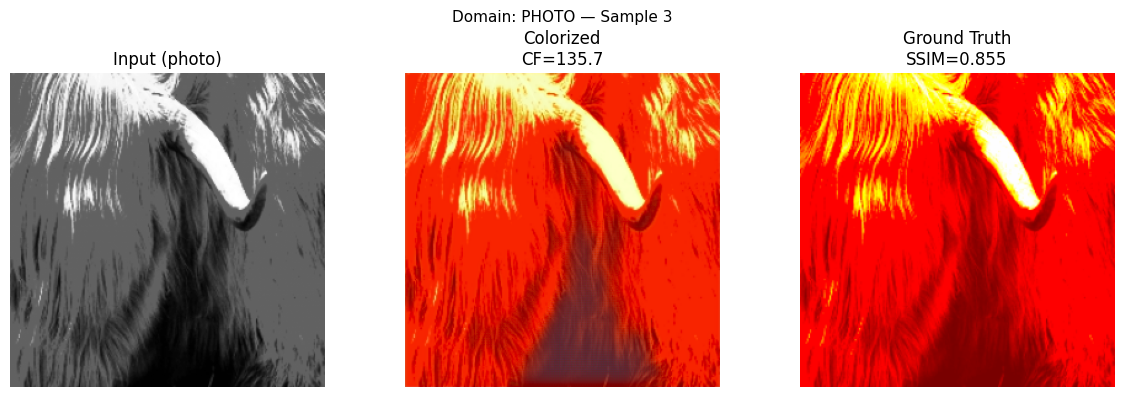

Saved result_3_photo.png — CF=135.7 SSIM=0.855


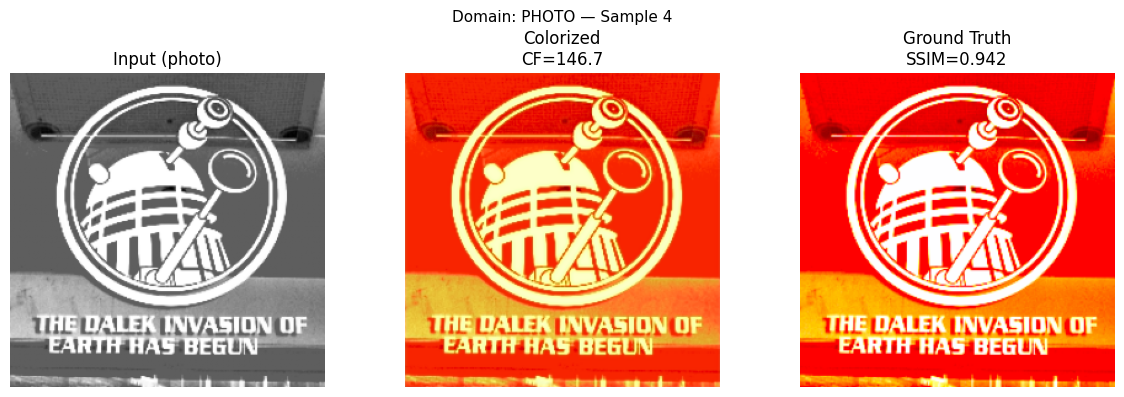

Saved result_4_photo.png — CF=146.7 SSIM=0.942


/tmp/ipykernel_3860/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2645 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2784 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


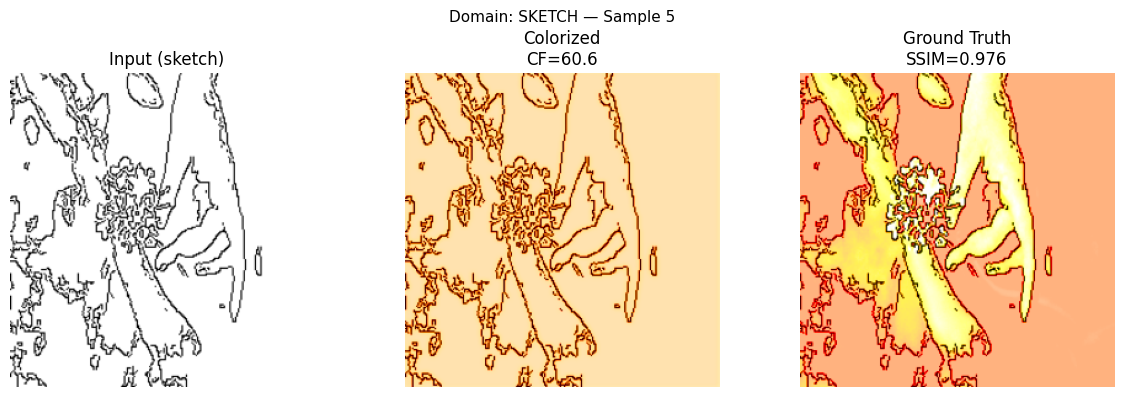

Saved result_5_sketch.png — CF=60.6 SSIM=0.976


/tmp/ipykernel_3860/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 9106 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 7260 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


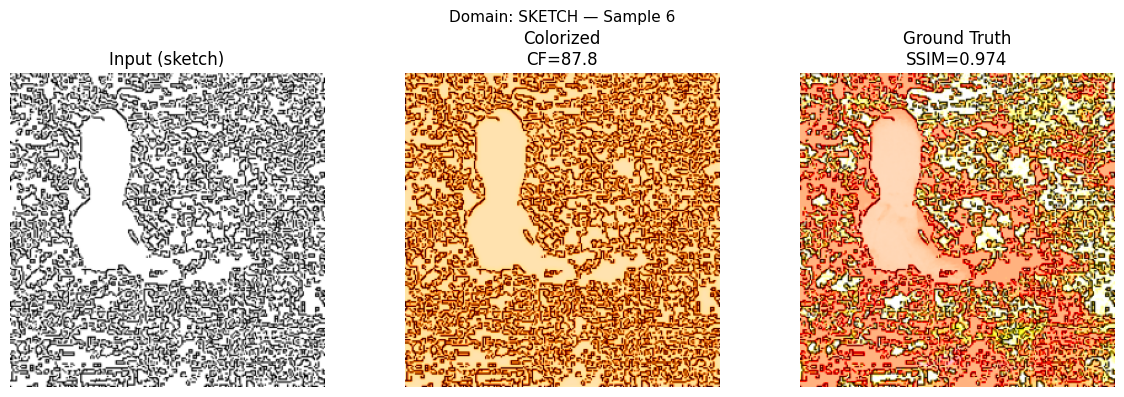

Saved result_6_sketch.png — CF=87.8 SSIM=0.974


/tmp/ipykernel_3860/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2244 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2059 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


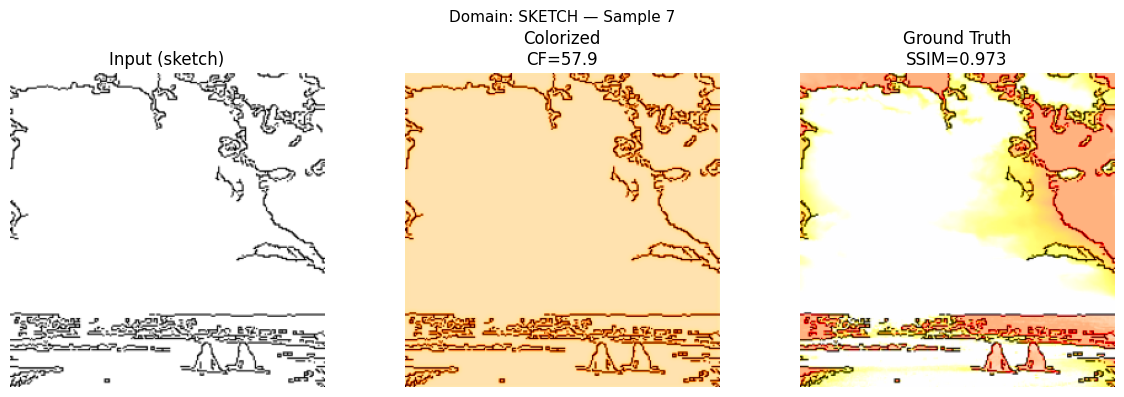

Saved result_7_sketch.png — CF=57.9 SSIM=0.973


/tmp/ipykernel_3860/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 4204 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_3860/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 4022 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


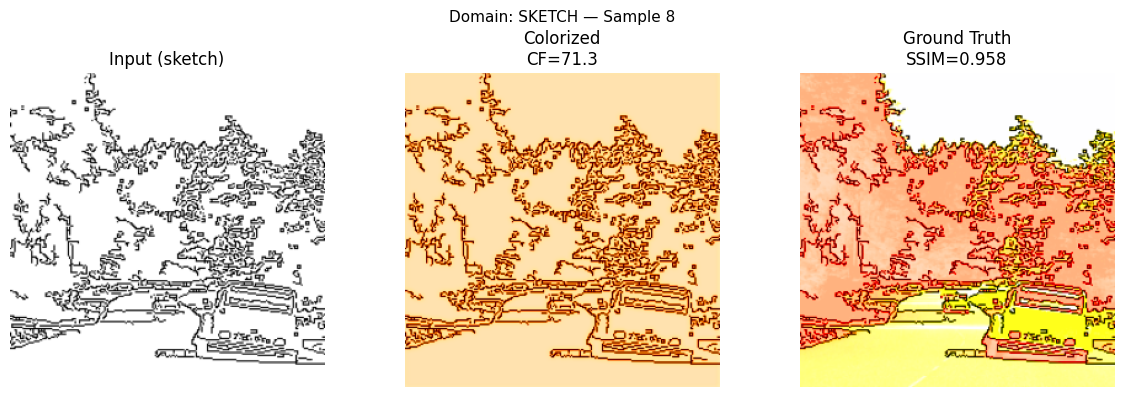

Saved result_8_sketch.png — CF=71.3 SSIM=0.958


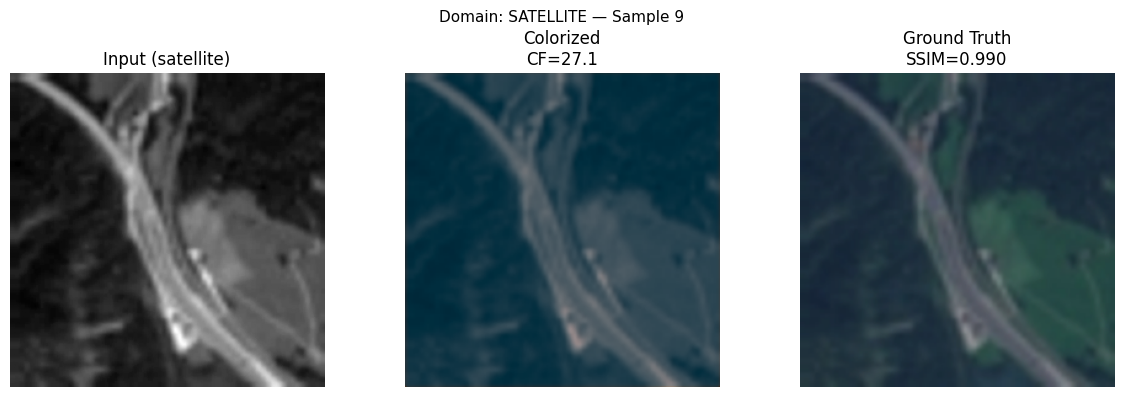

Saved result_9_satellite.png — CF=27.1 SSIM=0.990


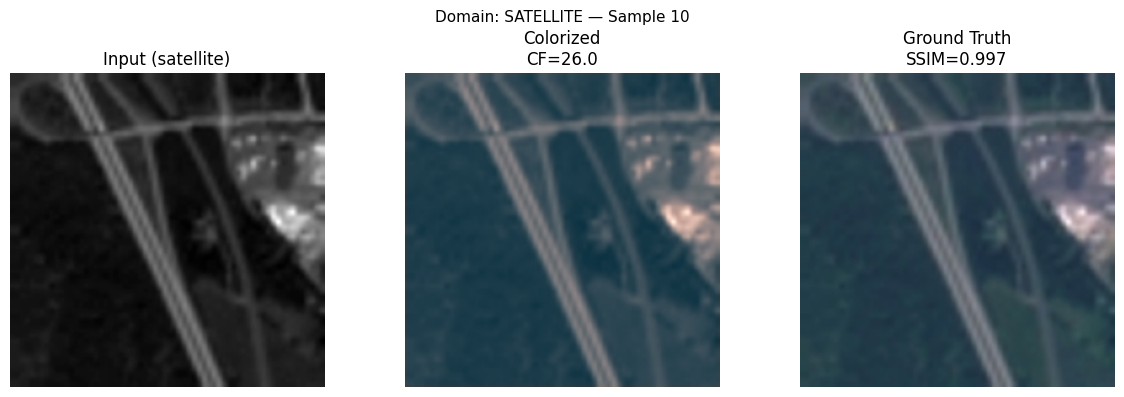

Saved result_10_satellite.png — CF=26.0 SSIM=0.997


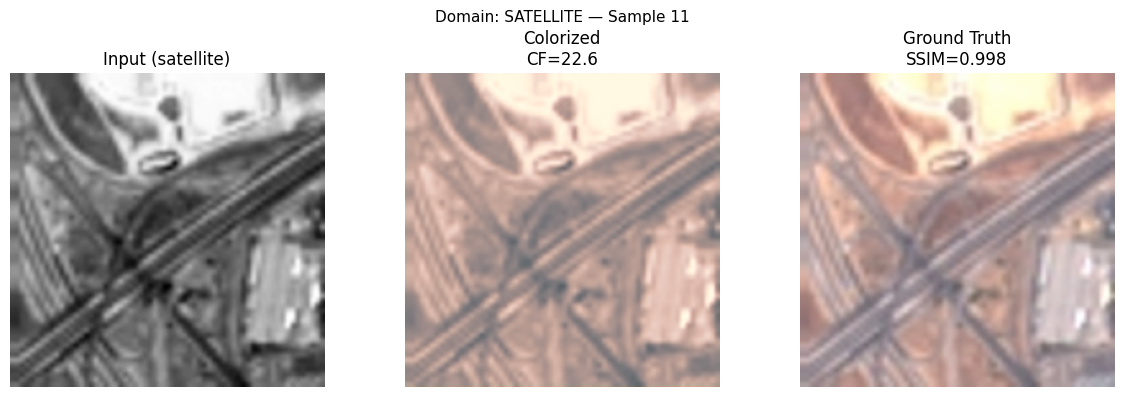

Saved result_11_satellite.png — CF=22.6 SSIM=0.998


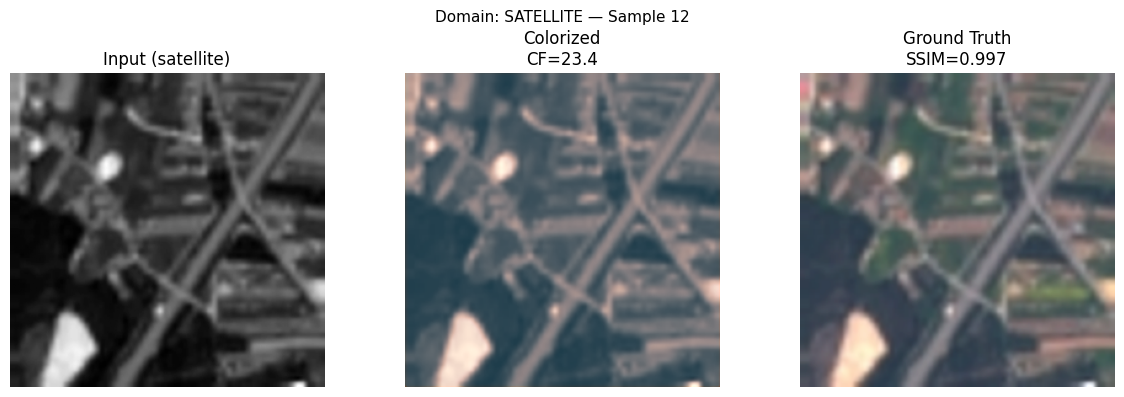

Saved result_12_satellite.png — CF=23.4 SSIM=0.997

All 12 results saved across 3 domains!


In [27]:
os.makedirs('gui_outputs', exist_ok=True)
model.eval()

domain_sample_ids = {d: [] for d in DOMAIN_NAMES}
for i in range(len(val_set)):
    _, _, lbl = val_set[i]
    d_name = DOMAIN_NAMES[lbl.item()]
    if len(domain_sample_ids[d_name]) < 4:
        domain_sample_ids[d_name].append(i)
    if all(len(v) >= 4 for v in domain_sample_ids.values()):
        break

result_count = 0
for d_name, ids in domain_sample_ids.items():
    for idx in ids:
        inp, tgt_ab, domain_lbl = val_set[idx]
        L_norm = inp[:1]
        with torch.no_grad():
            pred_ab = model(inp.unsqueeze(0).to(device)).squeeze(0).cpu()

        input_vis = np.clip((L_norm[0].numpy() + 1.0) * 127.5, 0, 255).astype(np.uint8)
        rgb_pred  = lab_to_rgb(L_norm, pred_ab)
        rgb_gt    = lab_to_rgb(L_norm, tgt_ab)

        cf = compute_colorfulness(rgb_pred)
        ss = compute_ssim(rgb_pred, rgb_gt)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(input_vis, cmap='gray'); axes[0].set_title(f'Input ({d_name})')
        axes[1].imshow(rgb_pred); axes[1].set_title(f'Colorized\nCF={cf:.1f}')
        axes[2].imshow(rgb_gt);   axes[2].set_title(f'Ground Truth\nSSIM={ss:.3f}')
        for ax in axes: ax.axis('off')
        plt.suptitle(f'Domain: {d_name.upper()} — Sample {result_count+1}', fontsize=11)
        plt.tight_layout()
        plt.savefig(f'gui_outputs/result_{result_count+1}_{d_name}.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f'Saved result_{result_count+1}_{d_name}.png — CF={cf:.1f} SSIM={ss:.3f}')
        result_count += 1

print(f'\nAll {result_count} results saved across {len(DOMAIN_NAMES)} domains!')

## Step 15: Save All Outputs

In [28]:
os.makedirs('task5_outputs', exist_ok=True)

for f in ['sketch_domain_demo.png', 'domain_samples.png', 'training_curves.png']:
    if os.path.exists(f): shutil.copy(f, f'task5_outputs/{f}')

if os.path.exists(f'{CHECKPOINT_DIR}/best_model.pth'):
    shutil.copy(f'{CHECKPOINT_DIR}/best_model.pth', 'task5_outputs/best_model.pth')

summary = {
    'task':          'Task 5 - Cross-Domain Image Colorization',
    'base_project':  'Real-Time Image Colorization (Training)',
    'new_features':  ['Multi-domain training (photo/sketch/satellite)',
                      'Domain one-hot input (4ch)', 'Per-domain metric breakdown'],
    'domains':       DOMAIN_NAMES,
    'dataset':       'EuroSAT (satellite) + Kaggle photos + generated sketches',
    'epochs':        NUM_EPOCHS,
    'best_val_loss': round(best_val_loss, 4),
    'per_domain_ssim': {
        d: round(float(np.mean(domain_metrics[d]['ssim'])), 4)
        if domain_metrics[d]['ssim'] else None
        for d in DOMAIN_NAMES
    },
}

with open('task5_outputs/metrics_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All outputs saved to task5_outputs/')
print(json.dumps(summary, indent=2))

All outputs saved to task5_outputs/
{
  "task": "Task 5 - Cross-Domain Image Colorization",
  "base_project": "Real-Time Image Colorization (Training)",
  "new_features": [
    "Multi-domain training (photo/sketch/satellite)",
    "Domain one-hot input (4ch)",
    "Per-domain metric breakdown"
  ],
  "domains": [
    "photo",
    "sketch",
    "satellite"
  ],
  "dataset": "EuroSAT (satellite) + Kaggle photos + generated sketches",
  "epochs": 5,
  "best_val_loss": 0.0115,
  "per_domain_ssim": {
    "photo": 0.9289,
    "sketch": 0.9664,
    "satellite": 0.9962
  }
}


## Summary Table

| Component | Detail |
|-----------|--------|
| Base project | Real-Time Image Colorization (training project) |
| New addition | Domain router with 3 domains trained jointly |
| Model | CrossDomainColorizationUNet (4ch: L + domain one-hot) |
| Domains | Photo, Sketch (generated via Canny edges), Satellite (EuroSAT) |
| Epochs | 5 |
| Loss | Smooth L1 (Huber), tracked per-domain |
| Key experiment | Per-domain SSIM/Colorfulness breakdown |